# 📘 Tutorial 1: Why Model an Unknown Function?
> This is the worked version of the notebook.
>
> All cells have been executed and include outputs, figures, and numerical results for reference.

In **Part 2**, we studied optimisation from the perspective of **dynamics**, **geometry**, and **non-convexity**.

We saw that even a good optimiser can struggle when:
- the landscape contains multiple minima,
- gradients are noisy,
- and evaluations are limited by a finite compute budget.

In this tutorial, we shift attention to a new difficulty:

> **what if the objective function itself is not fully known?**

In many realistic optimisation problems, we cannot write down the objective analytically or inspect it everywhere.
Instead, we only learn about it by evaluating it at selected points — and each evaluation may be expensive, noisy, or time-consuming.

Once this happens, optimisation is no longer only about how to move on a landscape.

It also becomes a problem of:
- learning from sparse observations,
- deciding where to sample next,
- and using a limited evaluation budget as efficiently as possible.

To make this concrete, we study simple one-dimensional black-box objectives and introduce the idea of a **surrogate model**: a learned approximation that stands in for the unknown function and helps guide search.

---

**This tutorial is designed to shift perspective**
- from *“optimisation means directly minimising a known function”*
- to *“when evaluations are expensive, optimisation must begin by modelling the function itself.”*

---

**The emphasis is on developing intuition for**
- why expensive objectives make direct optimisation impractical,
- why sparse sampling creates an information bottleneck,
- how surrogate models turn limited observations into a usable approximation,
- why model complexity affects both fit quality and reliability,
- and how a surrogate can guide the choice of future evaluations.

---

**Key ideas explored include**
- unknown objectives as black-box functions,
- evaluation cost and data efficiency,
- sparse observations and sampling budgets,
- polynomial surrogates as first surrogate models,
- the trade-off between underfitting and overfitting,
- and the difference between uniform sampling and surrogate-guided search.

---

This tutorial serves as the conceptual bridge from **optimisation alone** to **model-guided optimisation**.

In particular, it shows that once the objective is expensive and only partially observed:
- the best solution found depends strongly on the sampling budget,
- modelling becomes part of the optimisation process itself,
- and intelligent search requires more than just local descent.

These ideas prepare the ground for the next tutorial, where we move beyond prediction alone and begin to study **uncertainty**, **confidence**, and why a useful surrogate must represent not only what it predicts, but also what it does not yet know.

---

**Recommended prerequisites**
- Completion of **Part 2**
- Basic familiarity with optimisation and objective functions
- Comfort with simple function fitting and plots

---

**Author**: Angze Li

**Last updated**: 2026-03-30

**Version**: v1.0

## 🔧 Setup

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)


def set_seed(seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)


def style_ax(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    ax.tick_params(axis="both", labelsize=14)
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight("bold")


set_seed(0)

## 1. An unknown objective function

In previous parts of the repository, we mostly studied optimisation problems in which the objective function was fully known.
We could write it down analytically, compute its gradient exactly, and directly analyse its geometry.

In many real scientific and engineering problems, however, this is no longer possible.

Instead, we often face an **unknown objective function**:
- we do not know its full analytical form,
- we may only observe it by querying or evaluating it at selected points,
- and each evaluation may be expensive, noisy, or time-consuming.

This is the setting in which **surrogate modelling** becomes necessary.

---

### What the code does

- `expensive_objective(x)` defines a smooth 1D function with multiple scales and mild nonlinearity.
- In this tutorial, we will **pretend that this function is unknown** and treat it as a black box.
- We evaluate it on a dense grid only for visualisation, so that we can see what the true function looks like.
- The resulting curve is plotted over the interval $[-3, 3]$.

Although we can see the full function here, that is only for teaching purposes.
The key idea is to imagine that in practice, we would **not** have access to this full curve.

---

### Why study an unknown objective function?

This is the central motivation for Part 3.

If the objective is unknown and expensive to evaluate, then direct optimisation becomes difficult because:

- we cannot inspect the whole landscape,
- we cannot afford to evaluate the function everywhere,
- and we may not have access to reliable gradients.

So instead of directly minimising the true function, we need a different strategy:

> **build a model of the function from limited observations, and use that model to guide where to evaluate next.**

This is the core idea behind **surrogate modelling** and, eventually, **Bayesian Optimisation**.

---

### Why this matters

Once the objective is treated as unknown, optimisation changes in character.

It is no longer only a problem of:
- descending quickly,
- choosing a learning rate,
- or handling non-convexity.

It also becomes a problem of:
- learning from sparse data,
- reasoning under uncertainty,
- and deciding how to spend a limited evaluation budget.

This is why studying unknown objective functions is necessary:

> **real optimisation often begins not with a known formula, but with incomplete information.**

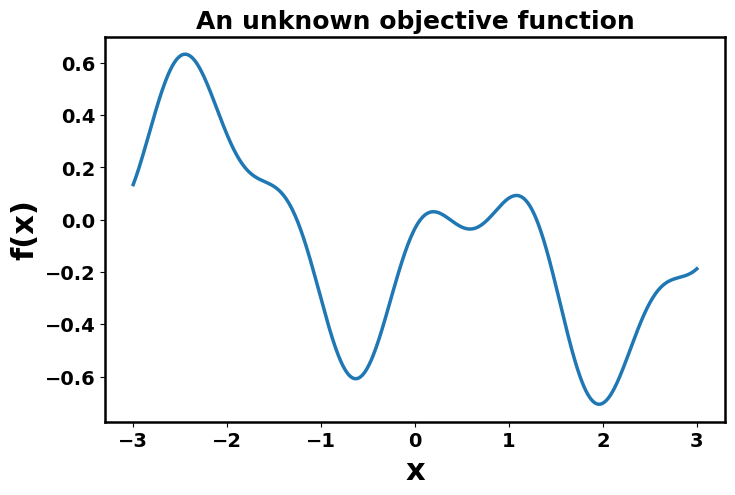

In [2]:
def expensive_objective(x):
    """
    A smooth 1D objective with multiple scales and mild nonlinearity.
    Treated as an expensive black-box function in this tutorial.
    """
    return 0.35 * torch.sin(2.2 * x) + 0.15 * torch.cos(5.0 * x) + 0.03 * (x - 1.5) ** 2 - 0.25


x_dense = torch.linspace(-3.0, 3.0, 600)
y_dense = expensive_objective(x_dense)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.5)
ax.set_title("An unknown objective function", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
style_ax(ax)
plt.show()

## 2. Direct evaluation becomes expensive quickly



In the previous cell, we introduced the idea of an **unknown objective function**.
The next question is: why can we not simply evaluate that function everywhere and then choose the best point directly?

The answer is practical rather than mathematical:

> **each function evaluation may carry a real cost.**

Depending on the application, one evaluation might mean:
- running a laboratory experiment,
- performing a simulation,
- training a model,
- or waiting for a physical measurement.

When evaluations are expensive, optimisation is no longer just about finding a good point — it is about finding a good point **with as few evaluations as possible**.

---

### What the code does

The helper function

```python
def evaluation_cost(n_points, cost_per_eval=1.0):
    return n_points * cost_per_eval
```
defines a very simple model of evaluation cost.

It assumes:
- each function evaluation has the same cost
- the **total cost** grows linearly with the number of evaluations.

We then compute that total cost for several evaluation budgets:

$$
5,;10,;20,;50,;100,;300.
$$

The resulting plot shows how the total cost increases as we ask for more and more function values.

---

### What does “relative cost” mean here?

The y-axis is labelled relative cost because the numbers in the plot are not meant to represent a specific physical unit such as pounds, seconds, or joules.

Instead, they represent cost **relative to one evaluation**.

So if we set

$$
\text{cost per evaluation} = 1,
$$

then:
- 5 evaluations cost 5 units,
- evaluations cost 10 units,
- 100 evaluations cost 100 units.

The important point is not the absolute number itself, but the scaling:

> **more evaluations always mean more total cost.**

In a real application, those “units” could correspond to:
- hours of lab time,
- CPU/GPU hours,
- materials consumed,
- money spent.

---

### Why this matters for optimisation

This is where optimisation becomes a practical decision-making problem.

If evaluations are cheap, we can afford to sample densely and inspect the objective in great detail.

But if evaluations are expensive, that is no longer realistic.

In that case, the key question becomes:

> **How can we learn as much as possible about the objective while spending as little evaluation budget as possible?**

This is exactly why **surrogate modelling** is useful.

Instead of evaluating the true function everywhere, we aim to:
- gather a small number of informative observations,
- build a model from them,
- use that model to decide where to evaluate next.

So this simple “relative cost” plot is not just a toy calculation — it captures the central practical constraint that motivates the rest of Part 3 and, eventually, **Bayesian Optimisation**.

---

### Key takeaway

> In many real problems, the main bottleneck is not computation of the optimiser itself, but the cost of evaluating the objective.

That is why data efficiency matters so much:
- fewer evaluations means lower practical cost,
- better modelling means each evaluation can be used more intelligently.

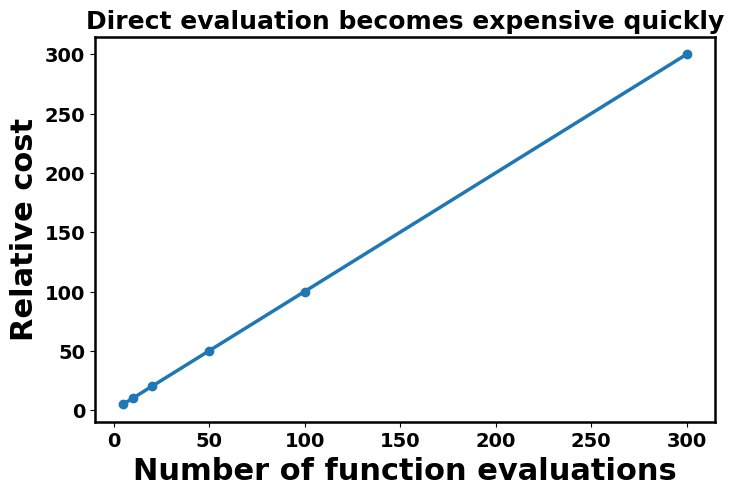

In [3]:
def evaluation_cost(n_points, cost_per_eval=1.0):
    return n_points * cost_per_eval


evaluation_budgets = [5, 10, 20, 50, 100, 300]
relative_costs = [evaluation_cost(n) for n in evaluation_budgets]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(evaluation_budgets, relative_costs, "-o", linewidth=2.5)
ax.set_title("Direct evaluation becomes expensive quickly", fontsize=18, fontweight="bold")
ax.set_xlabel("Number of function evaluations", fontsize=22, fontweight="bold")
ax.set_ylabel("Relative cost", fontsize=22, fontweight="bold")
style_ax(ax)
plt.show()

## 3. Sparse observations: why sampling matters

Once the objective function is treated as **unknown**, we can no longer assume access to its full curve.
Instead, the only information available comes from a limited number of **sampled evaluations**.

This is why **sampling** becomes such an important concept.

---

### What does “sampling” mean here?

In this tutorial, *sampling* means:

> choosing a small set of input locations $x$ at which we actually evaluate the unknown objective function.

Formally, instead of knowing the full function $f(x)$, we only observe a dataset of the form

$$
\{(x_1, f(x_1)), (x_2, f(x_2)), \dots, (x_n, f(x_n))\}.
$$

These sampled points are the only information we have about the objective.

Everything that follows — modelling, prediction, uncertainty estimation, and decision-making — must be based on these observations.

---

### What the code does

The helper function
 ```python
def sample_objective(n_points, x_min=-3.0, x_max=3.0):
    x_train = torch.linspace(x_min, x_max, n_points)
    y_train = expensive_objective(x_train)
    return x_train, y_train
```
generates a set of evenly spaced sample points across the input range and evaluates the objective at those points.

The figure then compares three different sampling budgets:

- 6 observations
- 12 observations
- 24 observations

In each panel:
- the solid curve shows the true objective (for teaching purposes only),
- the scatter points show the actual sampled observations.

---

### How to interpret the figure

The three panels illustrate a simple but important fact:

> **our understanding of the objective depends entirely on where and how densely we sample it.**

With only a small number of observations:
- much of the function remains unknown,
- important local structure may be missed,
- and any model built from the data will necessarily be uncertain.

As the number of sampled points increases:
- the observed structure becomes more informative,
- fine-scale variation is captured more clearly,
- and the objective becomes easier to model.

So sampling is not just data collection — it determines **what information is even available** to the optimiser.

---

### Why sampling is so important

In practice, sampling is the interface between the optimiser and the real world.

If evaluations are expensive, we cannot sample densely everywhere.
This means every evaluation has to matter.

A poor sampling strategy may:
- waste evaluations in uninformative regions,
- miss promising minima,
- or build a misleading model of the objective.

A good sampling strategy, on the other hand, can:
- reveal useful structure quickly,
- support more accurate modelling,
- and make optimisation far more data-efficient.

This is exactly why sampling lies at the heart of surrogate modelling and Bayesian Optimisation:

> **the quality of the optimisation depends not only on how we model the function, but also on where we choose to sample it.**

---

### Key takeaway

> In an unknown-function setting, optimisation begins with sampling.

Before we can predict, optimise, or reason under uncertainty, we first need observations — and those observations come from a limited, costly sampling process.

That is why sampling is so central:
- it defines the data,
- the data shapes the model,
- and the model guides the next evaluation.

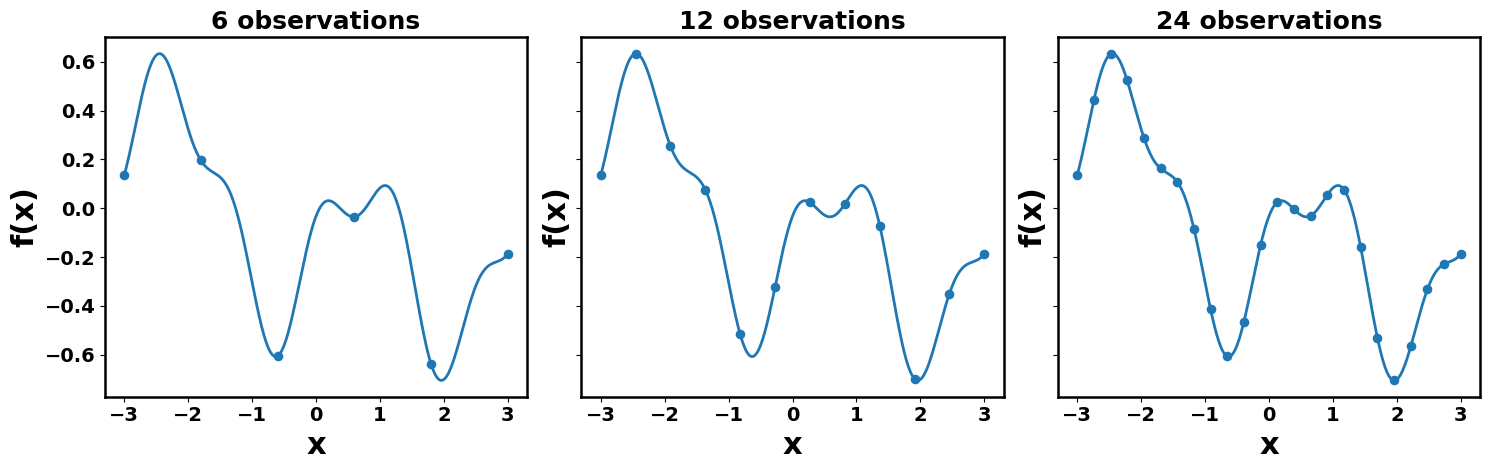

In [4]:
def sample_objective(n_points, x_min=-3.0, x_max=3.0):
    x_train = torch.linspace(x_min, x_max, n_points)
    y_train = expensive_objective(x_train)
    return x_train, y_train


sample_sizes = [6, 12, 24]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, n in zip(axes, sample_sizes):
    x_train, y_train = sample_objective(n)
    ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0)
    ax.scatter(x_train.numpy(), y_train.numpy(), s=35, zorder=3)
    ax.set_title(f"{n} observations", fontsize=18, fontweight="bold")
    ax.set_xlabel("x", fontsize=22, fontweight="bold")
    ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
    style_ax(ax)

plt.tight_layout()
plt.show()

## 4. The best observed value depends strongly on evaluation budget

Once we only observe the objective through a limited number of sampled points, the “best solution we have seen so far” becomes a budget-dependent quantity.

This is an important shift in perspective.

In a fully known optimisation problem, we can in principle locate the true minimum directly.
But in an unknown-function setting, we do not know the true minimum in advance.
Instead, we only know the **best value among the points we have actually evaluated**.

---

### What the code does

The helper function `best_observed_value(x_train, y_train)` simply finds the smallest observed function value in the sampled dataset.

For each evaluation budget

$$
2,\;4,\;6,\;8,\;12,\;16,\;20,\;30,
$$

we:

- sample the objective at that many points,
- identify the lowest observed value,
- and record it.

The plot then shows how this best observed value changes as the number of evaluations increases.

---

### What does “best observed value” mean?

The best observed value is exactly what its name suggests:

> the lowest function value that has actually been seen among the sampled points.

If our sampled dataset is

$$
\{(x_1, f(x_1)), \dots, (x_n, f(x_n))\},
$$

then the best observed value is

$$
\min_{1 \le i \le n} f(x_i).
$$

This is not necessarily the true global minimum of the objective.

It is only the best value we have managed to discover **with the evaluations we have spent so far**.

---

### How to interpret the figure

The curve shows that the best observed value improves as the evaluation budget grows, but not in a perfectly smooth or guaranteed way.

This reflects a simple reality:

- with very few evaluations, we may completely miss the most promising regions of the objective,
- with more evaluations, we increase the chance of observing lower function values,
- but improvement depends on whether the additional sample points actually land near good regions.

So the figure illustrates an important fact:

> **finding a good value is partly a matter of how much budget we have, and partly a matter of where we choose to spend it.**

---

### Why this matters

This is one of the clearest motivations for surrogate modelling.

If the best observed value depends strongly on the number of evaluations, then brute-force sampling is inefficient:
- small budgets may miss good regions entirely,
- large budgets may be too expensive,
- and uniform sampling may waste evaluations in uninformative places.

What we really want is not just *more* evaluations, but **smarter evaluations**.

That is:

> use the limited budget to sample points that are more likely to improve the best observed value.

This is exactly the problem that surrogate models are designed to help with.

---

### Key takeaway

> In an unknown-function setting, the quality of the best solution found so far depends strongly on the evaluation budget.

This means that optimisation is no longer only about minimising a function.

It is also about:
- making good decisions under limited information,
- using evaluations efficiently,
- and improving the best observed value as quickly as possible.

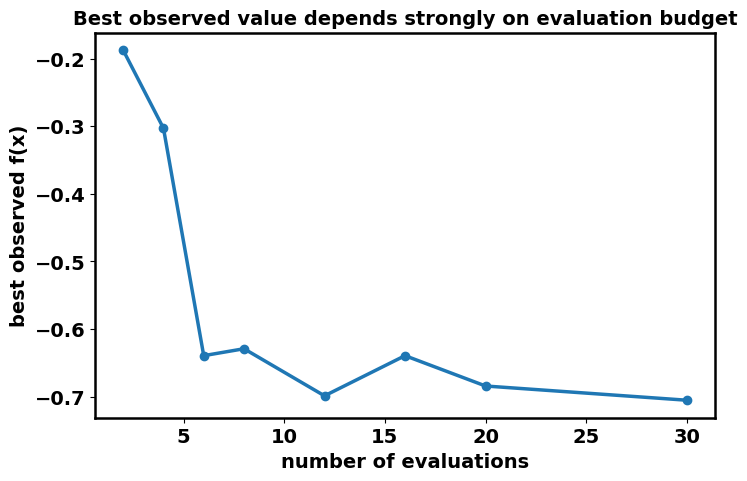

In [5]:
def best_observed_value(x_train, y_train):
    idx = torch.argmin(y_train)
    return x_train[idx], y_train[idx]


budgets = [2, 4, 6, 8, 12, 16, 20, 30]
xs_best, ys_best = [], []

for n in budgets:
    x_train, y_train = sample_objective(n)
    x_best, y_best = best_observed_value(x_train, y_train)
    xs_best.append(float(x_best))
    ys_best.append(float(y_best))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(budgets, ys_best, "-o", linewidth=2.5)
ax.set_title("Best observed value depends strongly on evaluation budget", fontsize=14, fontweight="bold")
ax.set_xlabel("number of evaluations", fontsize=14, fontweight="bold")
ax.set_ylabel("best observed f(x)", fontsize=14, fontweight="bold")
style_ax(ax)
plt.show()

## 5. A simple surrogate model: polynomial approximation

So far, we have treated the objective as an unknown function that can only be observed at a limited number of sampled points.

This creates a fundamental problem:

> we want to optimise the function, but we do not know its full shape, and we cannot afford to evaluate it everywhere.

This is exactly why **surrogate models** are important.

A surrogate model is a learned approximation to the unknown objective, built from the observations we have already collected.
Instead of working directly with the true function, we work with this cheaper, smoother, and more accessible stand-in.

In other words:

> **the surrogate is what turns a small set of expensive evaluations into a usable model of the objective.**

Without a surrogate, we only have isolated data points.
With a surrogate, we gain a continuous approximation that can be:
- visualised,
- queried cheaply,
- analysed,
- and eventually used to decide where to evaluate next.

---

### Why use a polynomial surrogate here?

In this cell, we use a **polynomial surrogate** as the simplest possible example.

Polynomials are useful because they are:

- easy to write down and fit,
- smooth and continuous,
- flexible enough to represent a range of shapes,
- and simple enough to illustrate the basic idea of surrogate modelling without introducing more advanced machinery yet.

This makes them a good teaching model for the central idea:

> from a small set of expensive observations, we fit a simpler function that approximates the unknown objective.

This is not meant to be the final modelling strategy for Bayesian Optimisation.
Rather, it is the first concrete example of what a surrogate is and why it matters.

---

### What the code does

The helper function `fit_polynomial_surrogate(x_train, y_train, degree)` fits a polynomial of a chosen degree to the observed data.

The helper function `eval_polynomial_surrogate(coeffs, x)` then evaluates that fitted polynomial on a dense grid.

In the figure, we:
- sample the objective at 10 training points,
- fit three surrogate models of different degrees,
- and compare each fitted surrogate to the true objective.

The three polynomial degrees used are:

- degree 3
- degree 5
- degree 9

---

### How to interpret the figure

Each panel compares:
- the **true objective**,
- the fitted **polynomial surrogate**,
- and the observed data points used for fitting.

This shows how the surrogate changes as model complexity increases.

- A **lower-degree polynomial** is smoother and simpler, but may not capture enough of the structure of the objective.
- A **higher-degree polynomial** has more flexibility and can fit the observed data more closely.

So increasing the degree gives the surrogate more expressive power.

---

### Does higher degree always mean higher precision?

Not necessarily.

A higher-degree polynomial can often fit the training observations more closely, because it has more free parameters and can bend more easily to match the sampled points.

So in that limited sense, higher degree can lead to **higher precision on the observed data**.

However, this comes with an important caveat:

> **More flexible surrogate models do not always give better overall approximations.**

If the degree becomes too large relative to the amount of data, the surrogate may begin to fit local quirks too aggressively.
This can make the model look more accurate at the observed points while behaving less reliably between them.

So the real lesson is:

- higher degree gives **more flexibility**
- more flexibility can improve fit
- but too much flexibility can reduce reliability

This is one of the first examples of the broader modelling trade-off between:
- **underfitting** (model too simple)
- and **overfitting** (model too complex)

---

### Why surrogate models matter

This cell is important not just because it introduces polynomials, but because it introduces the **role of a surrogate** in optimisation.

A surrogate model allows us to move from:

- a handful of disconnected sampled points

to:

- a continuous approximation of the objective that can support decision-making.

That is essential in expensive optimisation, because we cannot base intelligent search on raw samples alone.

The surrogate is what makes it possible to:
- estimate where promising regions may lie,
- reason about the objective between observed points,
- and eventually guide the next evaluation more efficiently than naive sampling.

So even though the polynomial model here is simple, the concept it introduces is fundamental:

> **surrogate modelling is the bridge between limited data and intelligent optimisation.**

---

### Key takeaway

This cell introduces one of the most important ideas of Part 3:

> when the true objective is unknown and expensive, we do not optimise it directly everywhere — we first build a surrogate.

Polynomial surrogates are a simple first example of that idea.
Later, we will move to more principled surrogate models that can do something even more powerful:

- not only make predictions,
- but also quantify **uncertainty** about those predictions.

That will be the key step toward Gaussian Processes and Bayesian Optimisation.

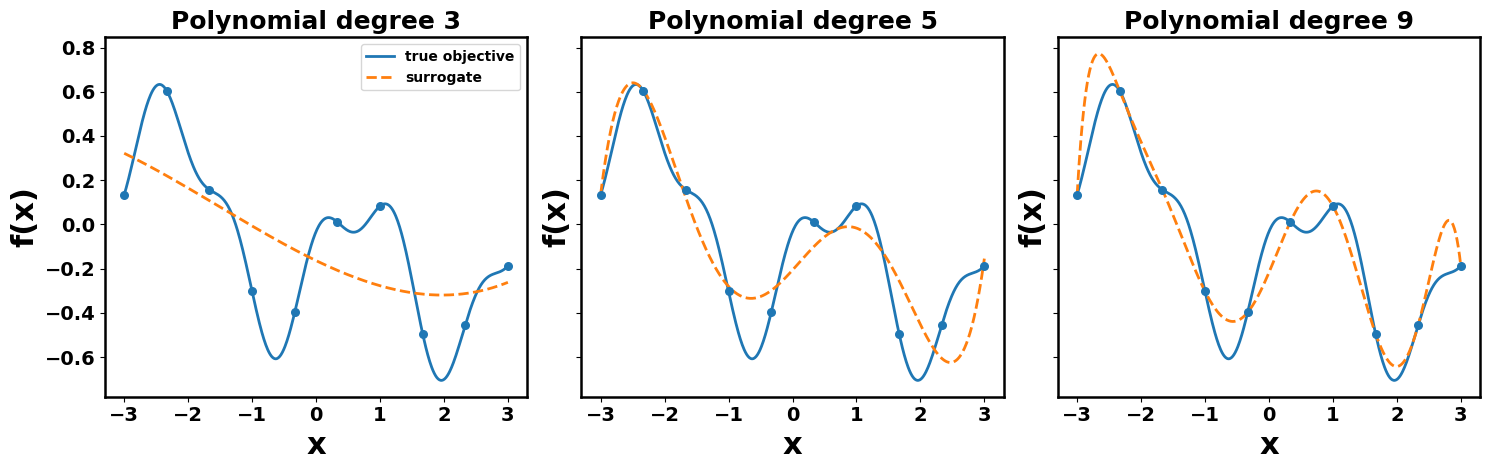

In [6]:
def fit_polynomial_surrogate(x_train, y_train, degree):
    coeffs = np.polyfit(x_train.numpy(), y_train.numpy(), degree)
    return coeffs


def eval_polynomial_surrogate(coeffs, x):
    y = np.polyval(coeffs, x.numpy())
    return torch.tensor(y, dtype=x.dtype)


x_train, y_train = sample_objective(10)
degrees = [3, 5, 9]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)

for ax, deg in zip(axes, degrees):
    coeffs = fit_polynomial_surrogate(x_train, y_train, degree=deg)
    y_pred = eval_polynomial_surrogate(coeffs, x_dense)

    ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="true objective")
    ax.plot(x_dense.numpy(), y_pred.numpy(), linewidth=2.0, linestyle="--", label="surrogate")
    ax.scatter(x_train.numpy(), y_train.numpy(), s=30, zorder=3)
    ax.set_title(f"Polynomial degree {deg}", fontsize=18, fontweight="bold")
    ax.set_xlabel("x", fontsize=22, fontweight="bold")
    ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
    style_ax(ax)

axes[0].legend(prop={"size": 10, "weight": "bold"})
plt.tight_layout()
plt.show()

## 6. Surrogate quality depends on model complexity

In the previous cell, we introduced the idea of fitting a surrogate model to a small set of observations.

A natural next question is:

> **How complex should the surrogate model be?**

If the surrogate is too simple, it may fail to capture the structure of the objective.
If it is too flexible, it may fit the observed data very closely but behave unreliably away from those points.

This cell explores that trade-off by measuring how the quality of a polynomial surrogate changes as we vary its degree.

---

### What the code does

We first define a helper function `mse(y_true, y_pred)` to compute the **mean squared error**:

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^n \big(y_i^{\mathrm{true}} - y_i^{\mathrm{pred}}\big)^2.
$$

This gives a quantitative measure of how closely the surrogate matches the target function.

We then:

- sample 8 training observations from the unknown objective,
- create a denser test grid across the same interval,
- fit polynomial surrogates of different degrees,
- and compute both:
  - the **training error** on the observed points,
  - and the **test error** on the dense grid.

The resulting plot compares these two errors as the polynomial degree increases.

---

### What is `coeffs` doing here?

The variable `coeffs` stores the polynomial coefficients returned by `np.polyfit(...)`.

For a polynomial of degree \(d\), the fitted surrogate has the form

$$
p_d(x) = a_d x^d + a_{d-1} x^{d-1} + \cdots + a_1 x + a_0,
$$

and `coeffs` is the array

$$
[a_d,\; a_{d-1},\; \dots,\; a_1,\; a_0].
$$

So `coeffs` is not the surrogate value itself — it is the set of parameters that defines the fitted polynomial.

Later, the function `eval_polynomial_surrogate(coeffs, x)` uses these coefficients to evaluate the surrogate at arbitrary input points.

In that sense:

- `fit_polynomial_surrogate(...)` **learns** the surrogate parameters,
- `eval_polynomial_surrogate(...)` **uses** those parameters to make predictions.

---

### How to interpret the figure

The plot shows two curves:

- **train MSE**: error on the observed training points
- **test MSE**: error on the denser grid representing the broader function

These curves reveal how surrogate quality changes with model complexity.

Typically:

- for **low-degree polynomials**, both train and test error may be relatively high, because the model is too simple to capture the function well,
- as the degree increases, the surrogate becomes more flexible and can fit the observations more accurately,
- but beyond a certain point, increasing complexity may stop improving the overall approximation and can even make the surrogate less reliable.

This is the classical tension between:
- **underfitting**: model too simple
- **overfitting**: model too flexible

---

### Why does Python warn that “polyfit may be poorly conditioned”?

When you fit high-degree polynomials, NumPy may display a warning such as:

> `RankWarning: Polyfit may be poorly conditioned`

This warning is normal in this experiment.

It appears because fitting a high-degree polynomial from a small number of data points can become **numerically unstable**.

More specifically:

- the polynomial basis $[1, x, x^2, x^3, \dots]$ becomes increasingly ill-conditioned at high degree,
- small changes in the data can lead to large changes in the fitted coefficients,
- and the resulting polynomial may be mathematically valid but numerically unreliable.

So the warning is telling you:

> **the fitted coefficients may not be stable enough to trust fully.**

This is not a bug in the code.
It is actually part of the lesson:

- high-degree surrogate models can become unstable,
- and more flexibility is not automatically better.

---

### Why this matters

This cell highlights a key modelling principle:

> **A useful surrogate must balance expressiveness with stability.**

If the surrogate is too simple, it misses important structure.
If it is too flexible, it may fit the known data closely while becoming numerically fragile or misleading elsewhere.

This is one of the main reasons why we eventually move beyond polynomial surrogates toward more principled models such as **Gaussian Processes**.

---

### Key takeaway

- `coeffs` stores the fitted polynomial parameters that define the surrogate.
- increasing model complexity can improve fit, but only up to a point,
- and the warning about poor conditioning is a reminder that very flexible polynomial surrogates can become unstable.

So this cell does more than compare errors:

> it shows that modelling is not only about fitting the data, but about choosing a surrogate that is expressive, stable, and trustworthy.

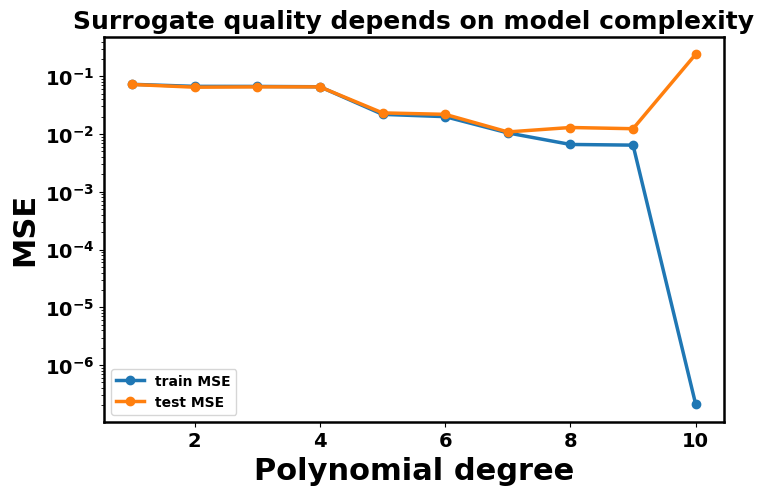

In [7]:
def mse(y_true, y_pred):
    return float(torch.mean((y_true - y_pred) ** 2))


x_train, y_train = sample_objective(12)
x_test = torch.linspace(-3.0, 3.0, 200)
y_test = expensive_objective(x_test)

degrees = list(range(1, 11))
train_errors = []
test_errors = []

for deg in degrees:
    coeffs = fit_polynomial_surrogate(x_train, y_train, degree=deg)
    y_train_pred = eval_polynomial_surrogate(coeffs, x_train)
    y_test_pred = eval_polynomial_surrogate(coeffs, x_test)
    train_errors.append(mse(y_train, y_train_pred))
    test_errors.append(mse(y_test, y_test_pred))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(degrees, train_errors, "-o", linewidth=2.5, label="train MSE")
ax.plot(degrees, test_errors, "-o", linewidth=2.5, label="test MSE")
ax.set_yscale("log")
ax.set_title("Surrogate quality depends on model complexity", fontsize=18, fontweight="bold")
ax.set_xlabel("Polynomial degree", fontsize=22, fontweight="bold")
ax.set_ylabel("MSE", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

## 7. A surrogate can propose promising points

Once a surrogate model has been fitted, it is no longer just a passive approximation of the objective.

It can also be used to make a decision:

> **where does the model predict that the objective is smallest?**

This is one of the most important reasons surrogate models matter in optimisation.

If the true objective is expensive to evaluate, we do not want to search blindly.
Instead, we would like the surrogate to suggest **promising candidate points** that are worth evaluating next.

---

### What the code does

For each polynomial degree

$$
4,\;6,\;10,
$$

we:

- fit a polynomial surrogate to the observed data,
- evaluate that surrogate on a dense grid,
- identify the point where the surrogate predicts the lowest value,
- and compare that predicted minimum to the true objective.

Each panel shows:

- the **true objective**,
- the fitted **surrogate**,
- the observed training points,
- the **predicted best point** according to the surrogate,
- and the **true global minimum** of the actual objective.

The printed output then reports, for each degree:

- the predicted best location,
- the surrogate value at that location,
- and the true objective value at that same point.

---

### How to interpret the figure

This figure shows that a surrogate model can turn a limited set of observations into a concrete optimisation proposal.

The star marks the point that the surrogate believes is most promising.

This is important because, in practice, we would not know the true objective everywhere.
So the optimiser must rely on the surrogate to decide where to evaluate next.

Comparing the star to the true objective tells us how useful that proposal actually is.

---

### What the printed values mean

For each polynomial degree, the code prints three quantities:

- **predicted best $x$**: the input location where the surrogate reaches its minimum
- **surrogate value**: the surrogate’s predicted objective value there
- **true objective there**: the actual value of the real objective at that same point

This comparison matters because a surrogate can be wrong in two different ways:

- it may place the predicted minimum at the wrong location,
- or it may predict an unrealistically optimistic function value there.

So the point is not just whether the surrogate has a minimum, but whether that minimum corresponds to a genuinely good point for the true objective.

---

### Why model complexity matters here

By comparing degrees 4, 6, and 10, we can see that the quality of the proposed point depends strongly on the surrogate itself.

A lower-degree surrogate may be too simple and place its minimum in the wrong region.
A moderate-degree surrogate may capture the structure more accurately.
A higher-degree surrogate may sometimes propose a point closer to the true minimum, but it may also become more unstable or overconfident.

So this figure extends the previous model-complexity discussion into an optimisation context:

> **surrogate quality affects not only prediction accuracy, but also the quality of the decisions made from the surrogate.**

---

### Why this matters

This is the first point in Part 3 where modelling becomes directly connected to optimisation.

We are no longer asking only:

- “how well does the surrogate fit the data?”

We are now asking:

- “can the surrogate help us choose a good next point?”

That is the real purpose of surrogate modelling in expensive optimisation.

A surrogate is useful not just because it approximates the function, but because it helps guide search more intelligently than uniform or brute-force evaluation.

---

### Key takeaway

> A surrogate model can propose promising evaluation points, but the quality of those proposals depends on the quality of the model itself.

This is a crucial bridge to Bayesian Optimisation.

Later, we will refine this idea further by introducing uncertainty:
- not just where the surrogate predicts a low value,
- but where the model is both **promising** and **uncertain**.

That is what turns surrogate modelling into a full sequential optimisation strategy.

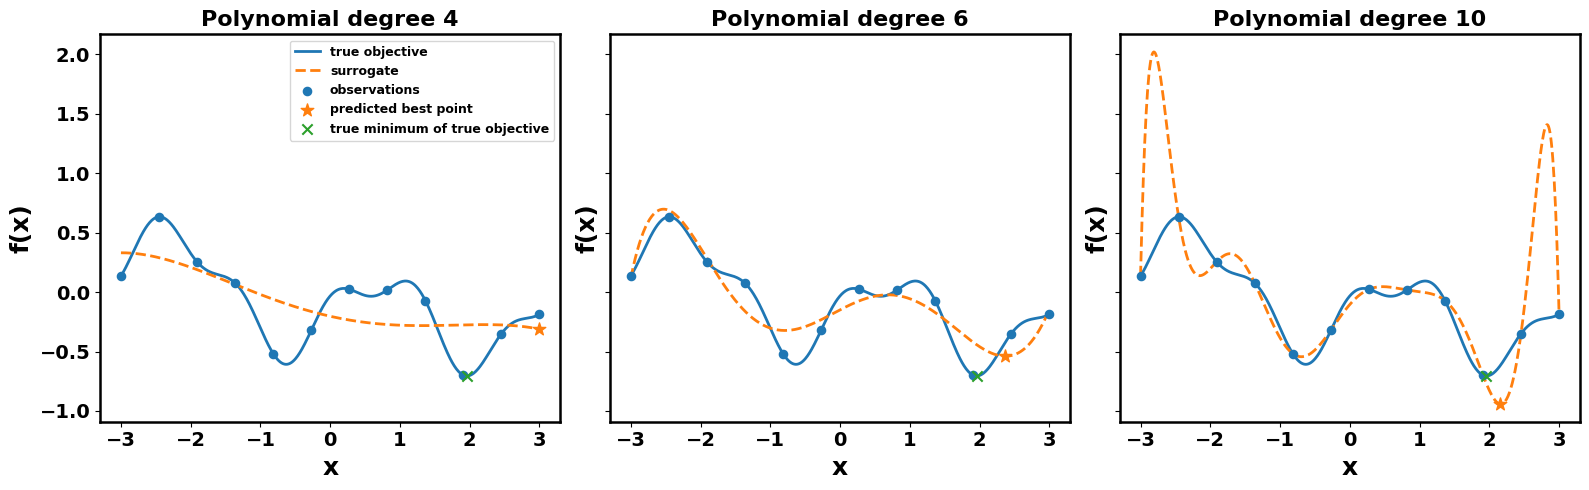

degree 4: predicted best x = 3.000, surrogate value = -0.312, true objective there = -0.187
degree 6: predicted best x = 2.369, surrogate value = -0.540, true objective there = -0.422
degree 10: predicted best x = 2.159, surrogate value = -0.943, true objective there = -0.617


In [8]:
def predicted_minimum_from_surrogate(coeffs, x_grid):
    y_pred = eval_polynomial_surrogate(coeffs, x_grid)
    idx = torch.argmin(y_pred)
    return x_grid[idx], y_pred[idx], y_pred

degrees = [4, 6, 10]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
results = []

x_true_min = x_dense[torch.argmin(y_dense)]
y_true_min = torch.min(y_dense)

for ax, deg in zip(axes, degrees):
    coeffs = fit_polynomial_surrogate(x_train, y_train, degree=deg)
    x_pred_min, y_pred_min, y_sur = predicted_minimum_from_surrogate(coeffs, x_dense)

    ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="true objective")
    ax.plot(x_dense.numpy(), y_sur.numpy(), linewidth=2.0, linestyle="--", label="surrogate")
    ax.scatter(x_train.numpy(), y_train.numpy(), s=35, zorder=3, label="observations")
    ax.scatter([float(x_pred_min)], [float(y_pred_min)], s=90, marker="*", zorder=4, label="predicted best point")
    ax.scatter([float(x_true_min)], [float(y_true_min)], s=55, marker="x", zorder=5, label="true minimum of true objective")
    ax.set_title(f"Polynomial degree {deg}", fontsize=16, fontweight="bold")
    ax.set_xlabel("x", fontsize=18, fontweight="bold")
    ax.set_ylabel("f(x)", fontsize=18, fontweight="bold")
    style_ax(ax)

    results.append((deg, float(x_pred_min), float(y_pred_min), float(expensive_objective(x_pred_min))))

axes[0].legend(prop={"size": 9, "weight": "bold"})
plt.tight_layout()
plt.show()

for deg, x_pred, y_pred, y_true in results:
    print(f"degree {deg}: predicted best x = {x_pred:.3f}, surrogate value = {y_pred:.3f}, true objective there = {y_true:.3f}")


## 8. How surrogate-guided sampling selects the next evaluation

Before comparing full sampling strategies, it is helpful to look at a **single step** of surrogate-guided search.

The central idea is simple:

- start with a small set of observed points,
- fit a surrogate model to those observations,
- use the surrogate to score candidate locations,
- and then choose the next evaluation point based on that model.

This is the basic mechanism that turns surrogate modelling into an optimisation strategy.

---

### What the code does

We begin with 5 initial observations, evenly spaced across the interval:

$$
x_{\mathrm{obs}} = \{-3.0,\,-1.5,\,0.0,\,1.5,\,3.0\}.
$$

The true objective is evaluated at those points, giving the current dataset.

A polynomial surrogate of degree 5 is then fitted to the observed data.

Next:

- a dense candidate grid is created across the input range,
- the surrogate is evaluated on that grid,
- and the point with the lowest surrogate value is identified as the most promising candidate.

However, we do **not** allow the new point to be chosen too close to any existing observation.

This is what the distance mask is doing:
- it computes how far each candidate point is from the existing observations,
- rejects candidate points that are too close,
- and only allows the surrogate to propose a genuinely new location.

The selected point is then evaluated on the **true objective**.

---

### What is the purpose of the distance mask?

Without the mask, the surrogate might simply choose a point extremely close to one that has already been evaluated.

That would not be a very useful new sample.

So the mask enforces a simple practical rule:

> **new evaluations should contribute new information rather than repeating nearly the same observation.**

This is not yet a full exploration strategy, but it prevents wasteful resampling and makes the sequential procedure more meaningful.

---

### How to interpret the figure

The figure shows four things at once:

- the **true objective**,
- the fitted **surrogate**,
- the **current observations**,
- and the **next selected point**.

The star marks the point that the surrogate proposes as the next evaluation.

This is the key transition from passive modelling to active search:

> the surrogate is no longer just describing the data — it is being used to choose what to do next.

The printed output then reports:
- the location of that next selected point,
- and the true objective value there.

---

### Why this matters

This cell illustrates the core logic of surrogate-guided optimisation:

1. observe a small number of points,
2. fit a model,
3. use the model to propose a promising next point,
4. evaluate the true objective there,
5. update the dataset,
6. repeat.

That is the essential structure that later becomes much more sophisticated in Bayesian Optimisation.

At this stage, the strategy is still very simple:
- the surrogate is a polynomial,
- the next point is chosen greedily,
- and uncertainty is not yet modelled.

But the underlying principle is already present:

> **use what has been learned so far to decide where the next expensive evaluation should go.**

---

### Key takeaway

This cell shows the first genuinely sequential idea in Part 3:

> a surrogate model can guide the next evaluation, not just fit the past data.

That is what makes surrogate modelling useful for optimisation.

Instead of spending evaluations uniformly or blindly, we begin to use the learned model to allocate the budget more intelligently.

/var/folders/n1/bmzcbfxs2fgc29_x3l4x_s_m0000gn/T/ipykernel_22791/2327893831.py:2: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_train.numpy(), y_train.numpy(), degree)


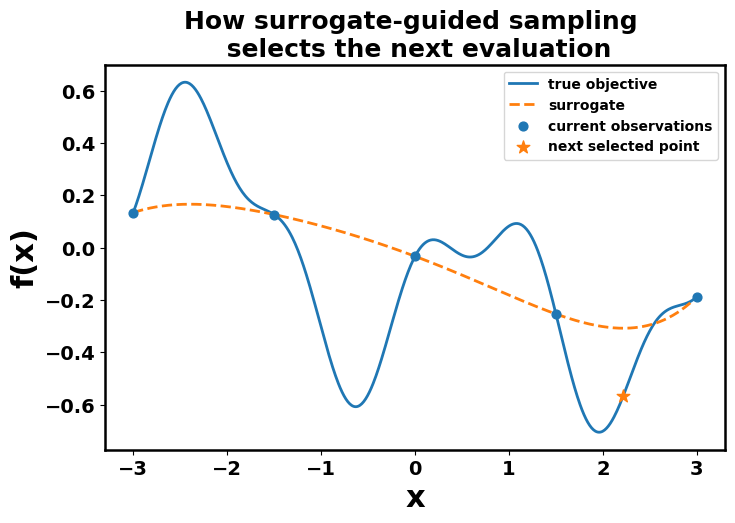

Next selected x: 2.218
True objective there: -0.565


In [9]:
x_obs = torch.linspace(-3.0, 3.0, 5)
y_obs = expensive_objective(x_obs)

coeffs = fit_polynomial_surrogate(x_obs, y_obs, degree=5)
candidate_grid = torch.linspace(-3.0, 3.0, 400)
y_pred = eval_polynomial_surrogate(coeffs, candidate_grid)

distances = torch.min(torch.abs(candidate_grid[:, None] - x_obs[None, :]), dim=1).values
mask = distances > 0.15

masked_scores = y_pred.clone()
masked_scores[~mask] = torch.max(y_pred) + 1.0

x_next = candidate_grid[torch.argmin(masked_scores)]
y_next_true = expensive_objective(x_next)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0, label="true objective")
ax.plot(candidate_grid.numpy(), y_pred.numpy(), linewidth=2.0, linestyle="--", label="surrogate")
ax.scatter(x_obs.numpy(), y_obs.numpy(), s=40, zorder=3, label="current observations")
ax.scatter([float(x_next)], [float(expensive_objective(x_next))], s=90, marker="*", zorder=4, label="next selected point")

ax.set_title("How surrogate-guided sampling \n selects the next evaluation", fontsize=18, fontweight="bold")
ax.set_xlabel("x", fontsize=22, fontweight="bold")
ax.set_ylabel("f(x)", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

print(f"Next selected x: {float(x_next):.3f}")
print(f"True objective there: {float(y_next_true):.3f}")

## 9. Uniform sampling vs surrogate-guided sampling

We are now ready to compare two different ways of spending the same evaluation budget on an unknown objective.

Both strategies begin with the same initial observations and use the same total number of function evaluations.
The difference is in **how the remaining evaluations are chosen**.

This comparison is important because it moves the discussion from:
- fitting a surrogate,
to
- using the surrogate to make sequential optimisation decisions.

---

### What the code does

Two sampling strategies are defined.

#### 1. `sequential_uniform_sampling(...)`

This is the baseline strategy.

It:
- starts with 5 evenly spaced observations,
- then continues adding new points in a fixed uniform pattern,
- regardless of what has already been observed.

So this strategy does **not** use the observed data to make decisions.
It simply covers the domain more densely.

#### 2. `sequential_surrogate_guided_sampling(...)`

This is the model-based strategy.

It also starts with the same 5 initial observations, but after that, each new point is chosen by:

- fitting a polynomial surrogate to the current data,
- evaluating that surrogate on a candidate grid,
- masking out points that are too close to already-sampled locations,
- and selecting the candidate with the lowest predicted surrogate value.

So this strategy uses the current model to decide where the next evaluation should go.

Both methods are then run with the same total budget:

$$
20 \text{ evaluations}.
$$

---

### How to interpret the figure

The two panels show the final sampled datasets produced by the two strategies.

#### Uniform sampling
The observations are spread out more evenly across the domain.

This gives broad coverage, but it also means that many evaluations are spent in regions that may not be especially promising.

#### Surrogate-guided sampling
The observations are more concentrated in regions that the surrogate believes are useful.

This reflects the central idea of model-guided optimisation:

> use the current data to focus future evaluations where good values are more likely to be found.

So the figure compares:

- **cover the space evenly**
versus
- **spend more evaluations in promising regions**

---

### What the printed values mean

The final two lines report the **best objective value found** by each strategy:

- the lowest value observed under uniform sampling
- the lowest value observed under surrogate-guided sampling

This gives a direct performance comparison under the same evaluation budget.

If the surrogate-guided strategy finds a lower value, that means the surrogate helped use the budget more effectively.

---

### Why this matters

This is one of the most important cells in the tutorial.

It demonstrates that a surrogate is not only a modelling tool — it is also a way to make optimisation more **data-efficient**.

Without a surrogate, we may spend many evaluations just covering the space.

With a surrogate, we can begin to allocate evaluations more intelligently:
- concentrate on promising regions,
- avoid wasting budget on clearly poor areas,
- and improve the chance of finding a good solution sooner.

This is the key bridge to Bayesian Optimisation:

> **the goal is not just to model the objective, but to use the model to decide where to evaluate next.**

---

### Key takeaway

> With the same number of expensive evaluations, a surrogate-guided strategy can find better points than naive uniform sampling.

That is the central motivation for the rest of Part 3 and Part 4:

- first learn a model of the unknown objective,
- then use that model to guide optimisation more intelligently than blind search.

/var/folders/n1/bmzcbfxs2fgc29_x3l4x_s_m0000gn/T/ipykernel_22791/2327893831.py:2: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_train.numpy(), y_train.numpy(), degree)


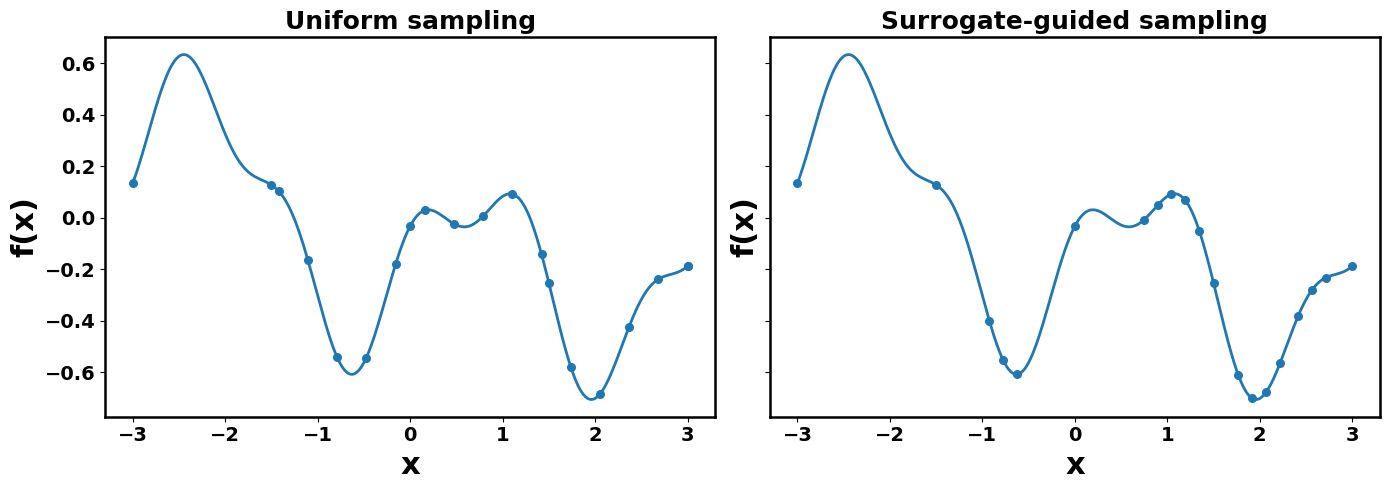

Best value from uniform sampling:   -0.684
Best value from surrogate sampling: -0.701


In [10]:
def sequential_uniform_sampling(initial_n=5, total_budget=20):
    x_obs = torch.linspace(-3.0, 3.0, initial_n)
    y_obs = expensive_objective(x_obs)

    while len(x_obs) < total_budget:
        x_new = torch.tensor([-3.0 + 6.0 * len(x_obs) / (total_budget - 1)], dtype=x_obs.dtype)
        y_new = expensive_objective(x_new)
        x_obs = torch.cat([x_obs, x_new])
        y_obs = torch.cat([y_obs, y_new])

    return x_obs, y_obs


def sequential_surrogate_guided_sampling(initial_n=5, total_budget=20, degree=5):
    x_obs = torch.linspace(-3.0, 3.0, initial_n)
    y_obs = expensive_objective(x_obs)

    for _ in range(total_budget - initial_n):
        coeffs = fit_polynomial_surrogate(x_obs, y_obs, degree=degree)
        candidate_grid = torch.linspace(-3.0, 3.0, 400)
        y_pred = eval_polynomial_surrogate(coeffs, candidate_grid)

        distances = torch.min(torch.abs(candidate_grid[:, None] - x_obs[None, :]), dim=1).values
        mask = distances > 0.15
        masked_scores = y_pred.clone()
        masked_scores[~mask] = torch.max(y_pred) + 1.0
        x_new = candidate_grid[torch.argmin(masked_scores)].unsqueeze(0)
        y_new = expensive_objective(x_new)

        x_obs = torch.cat([x_obs, x_new])
        y_obs = torch.cat([y_obs, y_new])

    return x_obs, y_obs


budget = 20
x_uni, y_uni = sequential_uniform_sampling(initial_n=5, total_budget=budget)
x_sur, y_sur = sequential_surrogate_guided_sampling(initial_n=5, total_budget=budget, degree=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0)
axes[0].scatter(x_uni.numpy(), y_uni.numpy(), s=30, zorder=3)
axes[0].set_title("Uniform sampling", fontsize=18, fontweight="bold")
axes[0].set_xlabel("x", fontsize=22, fontweight="bold")
axes[0].set_ylabel("f(x)", fontsize=22, fontweight="bold")
style_ax(axes[0])

axes[1].plot(x_dense.numpy(), y_dense.numpy(), linewidth=2.0)
axes[1].scatter(x_sur.numpy(), y_sur.numpy(), s=30, zorder=3)
axes[1].set_title("Surrogate-guided sampling", fontsize=18, fontweight="bold")
axes[1].set_xlabel("x", fontsize=22, fontweight="bold")
axes[1].set_ylabel("f(x)", fontsize=22, fontweight="bold")
style_ax(axes[1])

plt.tight_layout()
plt.show()

print(f"Best value from uniform sampling:   {float(torch.min(y_uni)):.3f}")
print(f"Best value from surrogate sampling: {float(torch.min(y_sur)):.3f}")

## 10. Why modelling can improve data efficiency

The previous cell compared the **final sampled points** produced by uniform sampling and surrogate-guided sampling.

This cell now compares the same two strategies in a more informative way:

> **how quickly does each strategy improve the best value found so far?**

This is a very useful perspective because, in expensive optimisation, we care not only about the final answer after the full budget is spent, but also about **how efficiently good solutions are found along the way**.

---

### What the code does

The helper function `cumulative_best(y_obs)` computes the best value found so far after each evaluation.

If the observed objective values are

$$
y_1, y_2, \dots, y_n,
$$

then the cumulative best sequence is

$$
\min(y_1),\;
\min(y_1, y_2),\;
\min(y_1, y_2, y_3),\;
\dots,\;
\min(y_1, \dots, y_n).
$$

So at every evaluation number, we track the **lowest objective value discovered up to that point**.

The code then:

- runs the uniform sampling strategy,
- runs the surrogate-guided sampling strategy,
- computes the cumulative best sequence for each one,
- and plots them against the evaluation number.

Finally, it prints the final best value reached by each strategy after the full budget of 20 evaluations.

---

### How to interpret the figure

Each curve shows how the best discovered objective value improves as more evaluations are spent.

- A **steeper early drop** means the strategy is finding good points quickly.
- A **lower curve overall** means the strategy is more effective at discovering promising regions under the same budget.

This makes the figure a direct measure of **data efficiency**.

If surrogate-guided sampling reaches lower values sooner, that means the surrogate is helping the optimiser use each evaluation more effectively.

---

### Why this matters

This is one of the clearest illustrations of why modelling is useful in expensive optimisation.

Without a surrogate, we may spend evaluations covering the space broadly but inefficiently.

With a surrogate, we can use the observations gathered so far to decide where the next evaluation is most likely to improve the current best result.

So the benefit of modelling is not only that it gives us a picture of the unknown objective.

It also changes the **rate at which useful progress is made**.

In other words:

> **a good surrogate can turn the same evaluation budget into faster improvement.**

---

### Why cumulative best is a good metric

The raw observed values can go up and down depending on where we sample next.

But in optimisation, what we usually care about most is:

> **what is the best solution found so far?**

That is why the cumulative best curve is such a natural measure.

It tells us, after each evaluation:
- how well the strategy has done up to that point,
- and how efficiently it is converting budget into progress.

---

### Key takeaway

> Modelling can improve data efficiency by helping the optimiser find better values sooner, not just eventually.

This is a central idea behind surrogate-based optimisation and Bayesian Optimisation:

- the number of evaluations is limited,
- so every evaluation should be chosen as intelligently as possible.

The cumulative-best comparison shows exactly why this matters:
- two methods may use the same budget,
- but the model-guided one can make that budget far more effective.

/var/folders/n1/bmzcbfxs2fgc29_x3l4x_s_m0000gn/T/ipykernel_22791/2327893831.py:2: RankWarning: Polyfit may be poorly conditioned
  coeffs = np.polyfit(x_train.numpy(), y_train.numpy(), degree)


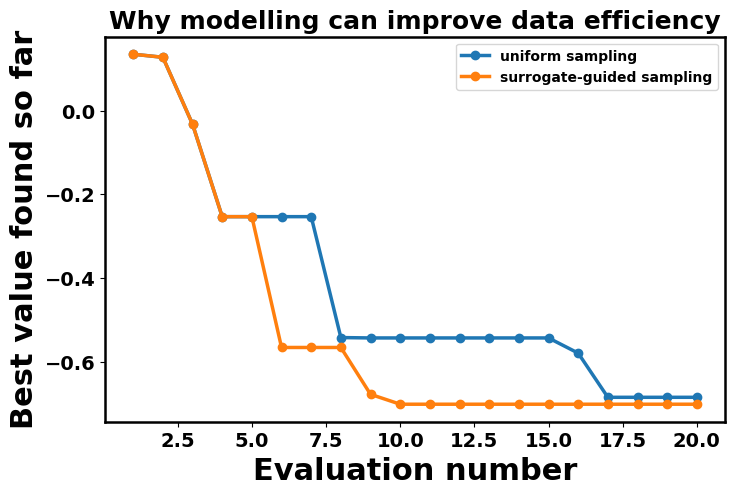

Final best value (uniform):   -0.684
Final best value (surrogate): -0.701


In [11]:
def cumulative_best(y_obs):
    vals = y_obs.numpy()
    return np.minimum.accumulate(vals)

budget = 20
x_uni, y_uni = sequential_uniform_sampling(initial_n=5, total_budget=budget)
x_sur, y_sur = sequential_surrogate_guided_sampling(initial_n=5, total_budget=budget, degree=5)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(1, budget + 1), cumulative_best(y_uni), "-o", linewidth=2.5, label="uniform sampling")
ax.plot(np.arange(1, budget + 1), cumulative_best(y_sur), "-o", linewidth=2.5, label="surrogate-guided sampling")
ax.set_title("Why modelling can improve data efficiency", fontsize=18, fontweight="bold")
ax.set_xlabel("Evaluation number", fontsize=22, fontweight="bold")
ax.set_ylabel("Best value found so far", fontsize=22, fontweight="bold")
ax.legend(prop={"size": 10, "weight": "bold"})
style_ax(ax)
plt.show()

print(f"Final best value (uniform):   {float(np.min(cumulative_best(y_uni))):.3f}")
print(f"Final best value (surrogate): {float(np.min(cumulative_best(y_sur))):.3f}")

## 🧭 Closing Remarks

In this tutorial, we made the transition from **optimising known objectives** to **reasoning about unknown ones**.

That shift is fundamental.

In earlier parts of the repository, the main challenge was how to move efficiently on a landscape we could already write down and analyse.
Here, the challenge is different:

> **the objective itself is not fully available to us.**

We only observe it through a small number of expensive evaluations.

---

By working through a simple 1D example, we saw that this immediately changes the optimisation problem.

A limited evaluation budget means that:
- we cannot inspect the whole function directly,
- the best value we find depends strongly on how many samples we can afford,
- and the quality of our decisions depends on how intelligently we use those samples.

This is why **sampling** and **evaluation efficiency** become central.

---

We then introduced the key idea of a **surrogate model**.

A surrogate is not the true objective.
It is a learned approximation built from sparse observations.

Even with simple polynomial surrogates, we were able to see that:
- a surrogate can capture useful structure from limited data,
- model complexity affects both fit quality and reliability,
- and the surrogate can be used not just to describe the function, but to **propose promising next evaluation points**.

This is the real conceptual turning point of the tutorial:

> **modelling is not separate from optimisation — it becomes part of the optimisation process itself.**

---

The final comparisons between uniform sampling and surrogate-guided sampling made this especially clear.

With the same total budget, the surrogate-guided strategy was able to:
- concentrate evaluations in more promising regions,
- improve the best value found more quickly,
- and use the available data more efficiently.

So the central lesson of this tutorial is:

> **When evaluations are expensive, optimisation is no longer just about descending — it is about learning where to look.**

That is exactly why modelling matters.

---

At the same time, this tutorial also showed the limitations of simple surrogates.

Polynomial models can be useful first examples, but they are:
- sensitive to model complexity,
- vulnerable to overfitting or poor conditioning,
- and unable to express uncertainty in a principled way.

That last point is especially important.

A surrogate that only gives a single prediction is not enough for true sequential decision-making.
To decide where to evaluate next, we also need to know:

- where the model is confident,
- where it is uncertain,
- and how prediction and uncertainty should be balanced.

---

This leads directly to the next tutorial.

In **Tutorial 2**, we will move beyond prediction alone and study:

> **uncertainty, confidence, and why modelling a function means modelling what we do not yet know about it.**

That is the next essential step toward **Gaussian Processes** and, eventually, **Bayesian Optimisation**.